# Self-Supervised Learning (Autoencoder)

Objective:
- Learn normal electricity consumption patterns
- Create latent embeddings
- Detect anomalies without using theft labels


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [5]:
df = pd.read_csv("../data/processed/feature_engineered_v2.csv")

df.head()


,consumer_id,timestamp,kwh,voltage,current,power_factor,theft_label,transformer_id,total_kwh,temperature,...,lag_1,lag_24,diff_1,diff_24,z_score,transformer_deviation,is_peak_hour,rolling_max_24h,rolling_min_24h,sudden_drop_flag
0,1,2024-01-01 00:00:00,1.408501,231.134680,6.600922,0.970170,0,T7,46.629769,25.086067,...,0.000000,0.0,0.000000,0.0,0.000000,-0.008255,0,1.408501,1.408501,0
1,1,2024-01-01 01:00:00,1.590901,226.709743,6.022453,0.949561,0,T7,49.026706,25.086067,...,1.408501,0.0,0.182400,0.0,0.707101,-0.006012,0,1.590901,1.408501,0
2,1,2024-01-01 02:00:00,1.539829,233.289587,6.373323,0.967279,0,T7,50.220320,25.086067,...,1.590901,0.0,-0.051072,0.0,0.284302,-0.007800,0,1.590901,1.408501,0
3,1,2024-01-01 03:00:00,1.215253,233.507623,5.297672,0.879270,0,T7,53.799312,25.086067,...,1.539829,0.0,-0.324576,0.0,-1.333025,-0.015873,0,1.590901,1.215253,0
4,1,2024-01-01 04:00:00,2.131333,231.189122,8.212522,0.987504,0,T7,54.309090,25.086067,...,1.215253,0.0,0.916079,0.0,1.619930,0.000783,0,2.131333,1.215253,0


In [6]:
feature_columns = [
    "kwh",
    "voltage",
    "current",
    "power_factor",
    "temperature",
    "humidity",
    "load_ratio",
    "rolling_mean_24h",
    "rolling_std_24h",
    "lag_1",
    "lag_24",
    "z_score",
    "transformer_deviation"
]

X = df[feature_columns]
y = df["theft_label"]


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [8]:
X_normal = X_scaled[y == 0]

X_train, X_val = train_test_split(
    X_normal,
    test_size=0.2,
    random_state=42
)

print("Training on normal samples only:", X_train.shape)


Training on normal samples only: (229978, 13)


In [9]:
input_dim = X_train.shape[1]
encoding_dim = 8

input_layer = keras.Input(shape=(input_dim,))

encoded = layers.Dense(16, activation="relu")(input_layer)
encoded = layers.Dense(encoding_dim, activation="relu")(encoded)

decoded = layers.Dense(16, activation="relu")(encoded)
decoded = layers.Dense(input_dim, activation="linear")(decoded)

autoencoder = keras.Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │           221 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 725 (2.83 KB)

 Trainable params: 725 (2.83 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=10,
    batch_size=256,
    validation_data=(X_val, X_val),
    verbose=1
)


Epoch 1/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.2743 - val_loss: 0.0607
Epoch 2/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0518 - val_loss: 0.0474
Epoch 3/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0390 - val_loss: 0.0257
Epoch 4/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0229 - val_loss: 0.0218
Epoch 5/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0215 - val_loss: 0.0215
Epoch 6/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0212 - val_loss: 0.0211
Epoch 7/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0210 - val_loss: 0.0211
Epoch 8/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0210 - val_loss: 0.0215
Epoch 9/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0210 - val_loss: 0.0210
Epoch 10/10
899/899 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0210 - val_loss: 0.0214


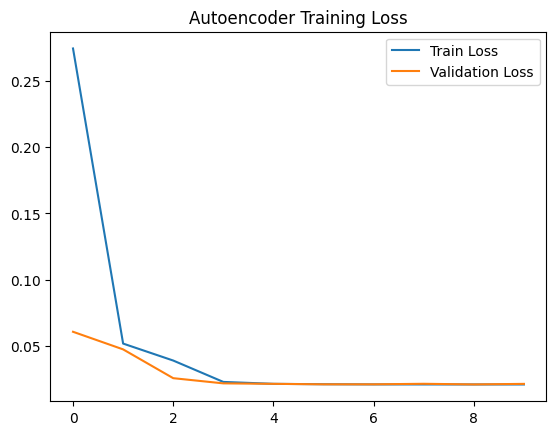

In [11]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Autoencoder Training Loss")
plt.show()


In [12]:
X_reconstructed = autoencoder.predict(X_scaled)

reconstruction_error = np.mean(
    np.square(X_scaled - X_reconstructed),
    axis=1
)

df["reconstruction_error"] = reconstruction_error


9000/9000 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


In [13]:
normal_error = df[df["theft_label"] == 0]["reconstruction_error"]
theft_error = df[df["theft_label"] == 1]["reconstruction_error"]

print("Normal Mean Error:", normal_error.mean())
print("Theft Mean Error:", theft_error.mean())


Normal Mean Error: 0.02133047178280102
Theft Mean Error: 0.19612636464665015


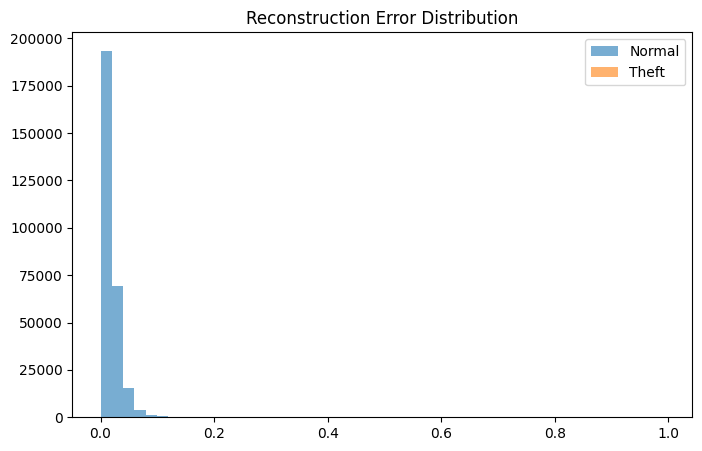

In [14]:
plt.figure(figsize=(8,5))
plt.hist(normal_error, bins=50, alpha=0.6, label="Normal")
plt.hist(theft_error, bins=50, alpha=0.6, label="Theft")
plt.legend()
plt.title("Reconstruction Error Distribution")
plt.show()


In [15]:
threshold = np.percentile(normal_error, 95)

df["autoencoder_anomaly_flag"] = (
    df["reconstruction_error"] > threshold
).astype(int)

print("Anomaly Threshold:", threshold)


Anomaly Threshold: 0.04884625976454204


In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df["theft_label"],
        df["autoencoder_anomaly_flag"]
    )
)


              precision    recall  f1-score   support

           0       1.00      0.95      0.97    287473
           1       0.03      0.80      0.05       527

    accuracy                           0.95    288000
   macro avg       0.51      0.87      0.51    288000
weighted avg       1.00      0.95      0.97    288000



In [17]:
df.to_csv("../data/processed/feature_engineered_with_autoencoder.csv", index=False)

print("Dataset with autoencoder features saved.")


Dataset with autoencoder features saved.


## Self-Supervised Learning Summary

1. Autoencoder trained only on normal data.
2. Model learned normal consumption patterns.
3. High reconstruction error indicates anomaly.
4. Anomaly score can be combined with classifier output.

Next Step:
- Train supervised classifier
- Combine anomaly score + theft probability
